# Analysis of Bitcoin's Relationship with Traditional Financial Assets
## DSA 210 — Introduction to Data Science | Spring 2025-2026
**Author:** Muizz Haider

This notebook presents a comprehensive exploratory data analysis (EDA) of Bitcoin (BTC), the S&P 500 Index, and Gold Futures, examining their relationships, correlations, and behaviors across different market conditions. The goal is to understand if Bitcoin behaves like a risk asset (like stocks) or a safe-haven asset (like gold).

---
## Section 0: Setup
First, we will install the required dependencies and import the necessary libraries.

In [6]:
!pip install -q yfinance seaborn scipy statsmodels

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')

# Define consistent color palette
colors = {'BTC': '#F7931A', 'SP500': '#1f77b4', 'Gold': '#FFD700'}
sns.set_palette(list(colors.values()))

---
## Section 1: Data Collection
We download historical daily data from Yahoo Finance for Bitcoin (BTC-USD), the S&P 500 (^GSPC), and Gold Futures (GC=F) from January 2020 to March 2026.

In [8]:
import yfinance as yf

# Define tickers and timeframe
tickers = {'BTC': 'BTC-USD', 'SP500': '^GSPC', 'Gold': 'GC=F'}
start_date = '2020-01-01'
end_date = '2026-03-31'

# Download data
raw_data = {}
for name, ticker in tickers.items():
    print(f"Downloading {name} data...")
    raw_data[name] = yf.download(ticker, start=start_date, end=end_date, progress=False)

print("\nData collection complete.")
for name, df in raw_data.items():
    print(f"{name}: {len(df)} rows, from {df.index.min().date()} to {df.index.max().date()}")


Data collection complete.
BTC: 2281 rows, from 2020-01-01 to 2026-03-30
SP500: 1568 rows, from 2020-01-02 to 2026-03-30
Gold: 1570 rows, from 2020-01-02 to 2026-03-30


---
## Section 2: Data Preparation & Enrichment
We extract the closing prices, merge them into a single DataFrame, and compute daily percentage returns and log returns.

In [11]:
# Extract Close prices
close_prices = pd.DataFrame({name: df['Close'].squeeze() for name, df in raw_data.items()})

# Forward-fill missing values (e.g., weekends for SP500/Gold where BTC still trades)
close_prices = close_prices.ffill().dropna()

# Compute daily returns
returns = close_prices.pct_change().dropna()

# Compute log returns
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()

print(f"Final dataset shape: {returns.shape}")
display(returns.head())

Final dataset shape: (2279, 3)


,BTC,SP500,Gold
Date,,,
2020-01-03,0.051452,-0.007060,0.016202
2020-01-04,0.008955,0.000000,0.000000
2020-01-05,0.000089,0.000000,0.000000
2020-01-06,0.048291,0.003533,0.010973
2020-01-07,0.050774,-0.002803,0.003576


---
## Section 3: Descriptive Statistics
Let's look at the central tendencies, dispersion, and shape of the return distributions.

In [12]:
# Descriptive statistics for daily returns
desc_stats = returns.describe().T
desc_stats['skewness'] = returns.skew()
desc_stats['kurtosis'] = returns.kurtosis()

# Annualized metrics (assuming 252 trading days for traditional assets)
desc_stats['annual_return'] = desc_stats['mean'] * 252
desc_stats['annual_volatility'] = desc_stats['std'] * np.sqrt(252)
desc_stats['sharpe_ratio_est'] = desc_stats['annual_return'] / desc_stats['annual_volatility']

display(desc_stats.style.format("{:.4f}").background_gradient(cmap='coolwarm', subset=['annual_return', 'annual_volatility', 'sharpe_ratio_est']))

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,annual_return,annual_volatility,sharpe_ratio_est
BTC,2279.0000,0.0015,0.0319,-0.3717,-0.0128,0.0003,0.0151,0.1875,-0.4667,11.3603,0.3799,0.5062,0.7504
SP500,2279.0000,0.0004,0.0108,-0.1198,-0.0019,0.0000,0.0038,0.0952,-0.3412,21.6789,0.0885,0.1716,0.5156
Gold,2279.0000,0.0005,0.0097,-0.1137,-0.0016,0.0000,0.0040,0.0608,-0.9023,13.9117,0.1323,0.1541,0.8587


**Interpretation:** Bitcoin shows significantly higher volatility compared to the S&P 500 and Gold. It also exhibits high kurtosis, meaning it has "fat tails" (extreme price movements are more common than a normal distribution would predict).

---
## Section 4: Price Analysis
Visualizing the raw prices, normalized prices, and cumulative returns to understand long-term trends.

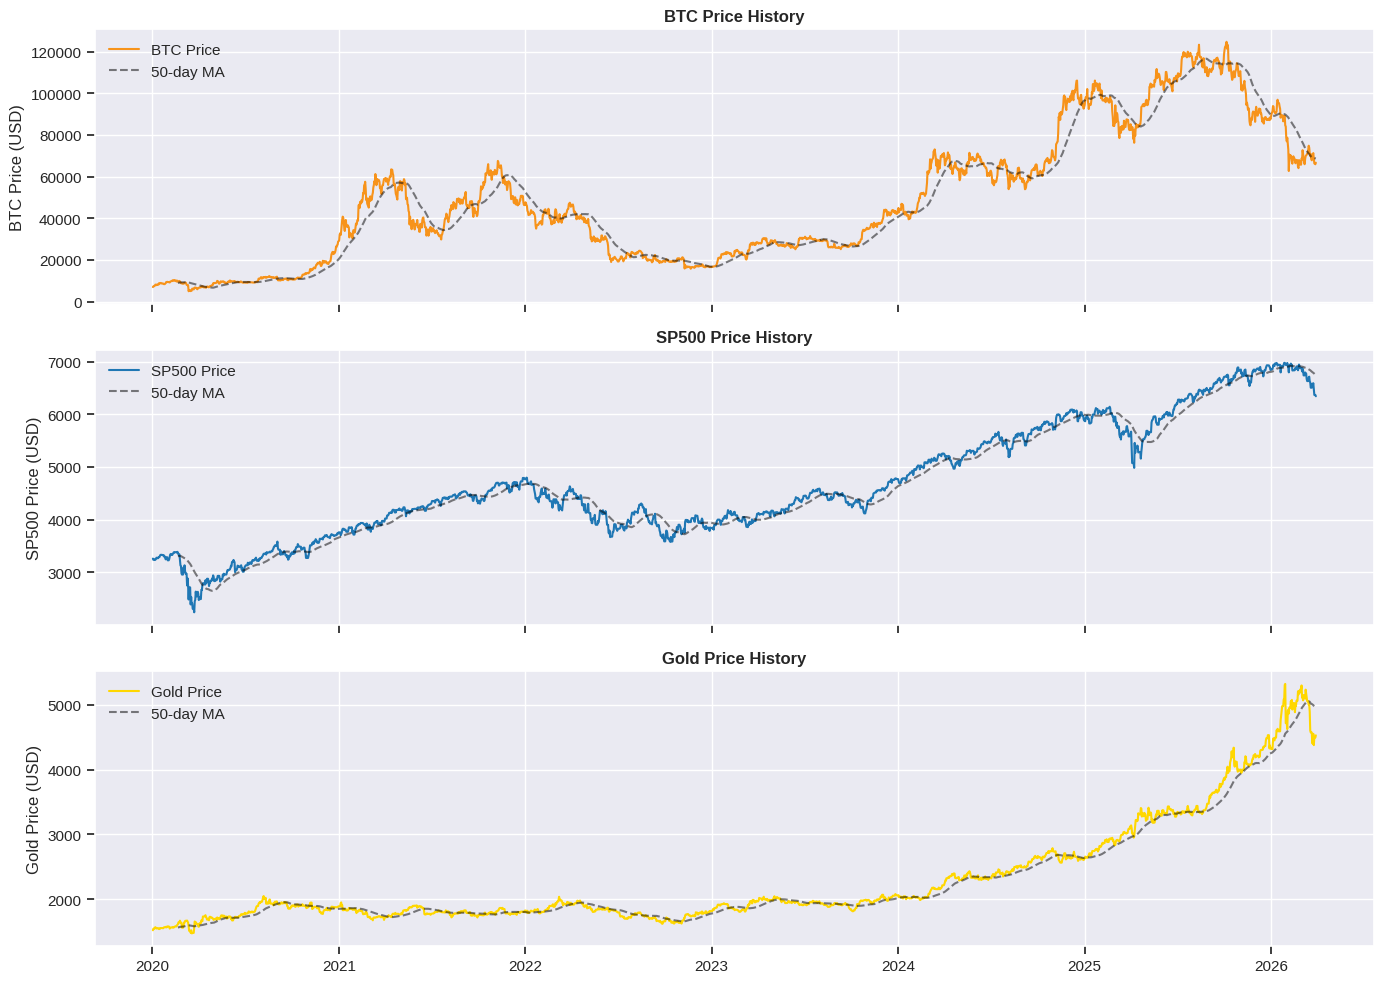

In [13]:
# Figure 1: Asset Prices Over Time
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for i, (asset, color) in enumerate(colors.items()):
    axes[i].plot(close_prices.index, close_prices[asset], color=color, label=f'{asset} Price')
    # Add 50-day moving average
    axes[i].plot(close_prices.index, close_prices[asset].rolling(50).mean(), color='black', alpha=0.5, linestyle='--', label='50-day MA')
    axes[i].set_ylabel(f'{asset} Price (USD)')
    axes[i].legend(loc='upper left')
    axes[i].set_title(f'{asset} Price History', fontweight='bold')

plt.tight_layout()
plt.show()

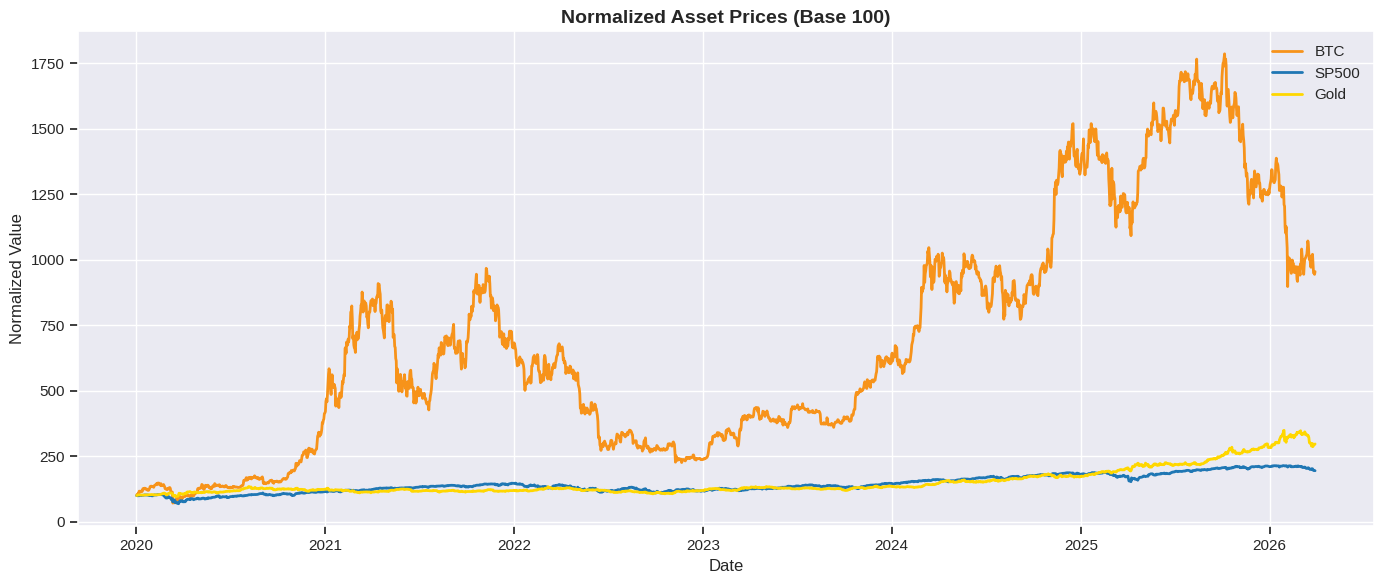

In [14]:
# Figure 2: Normalized Prices (Base 100)
normalized = (close_prices / close_prices.iloc[0]) * 100

plt.figure(figsize=(14, 6))
for asset, color in colors.items():
    plt.plot(normalized.index, normalized[asset], color=color, label=asset, linewidth=2)

plt.title('Normalized Asset Prices (Base 100)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Value')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

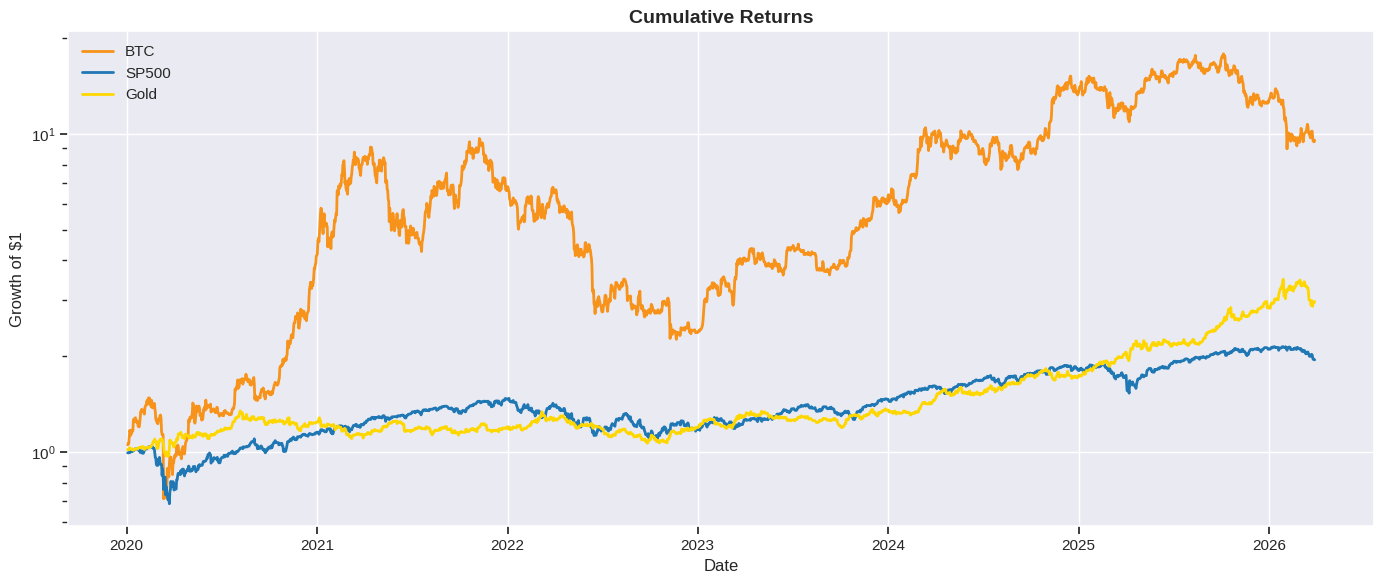

In [15]:
# Figure 3: Cumulative Returns
cumulative_returns = (1 + returns).cumprod()

plt.figure(figsize=(14, 6))
for asset, color in colors.items():
    plt.plot(cumulative_returns.index, cumulative_returns[asset], color=color, label=asset, linewidth=2)

plt.title('Cumulative Returns', fontsize=14, fontweight='bold')
plt.ylabel('Growth of $1')
plt.xlabel('Date')
plt.yscale('log') # Log scale for better visualization of exponential growth
plt.legend()
plt.tight_layout()
plt.show()

---
## Section 5: Return Distribution Analysis
Analyzing how daily returns are distributed. Normal distributions are often assumed in finance, but rarely hold true for crypto.

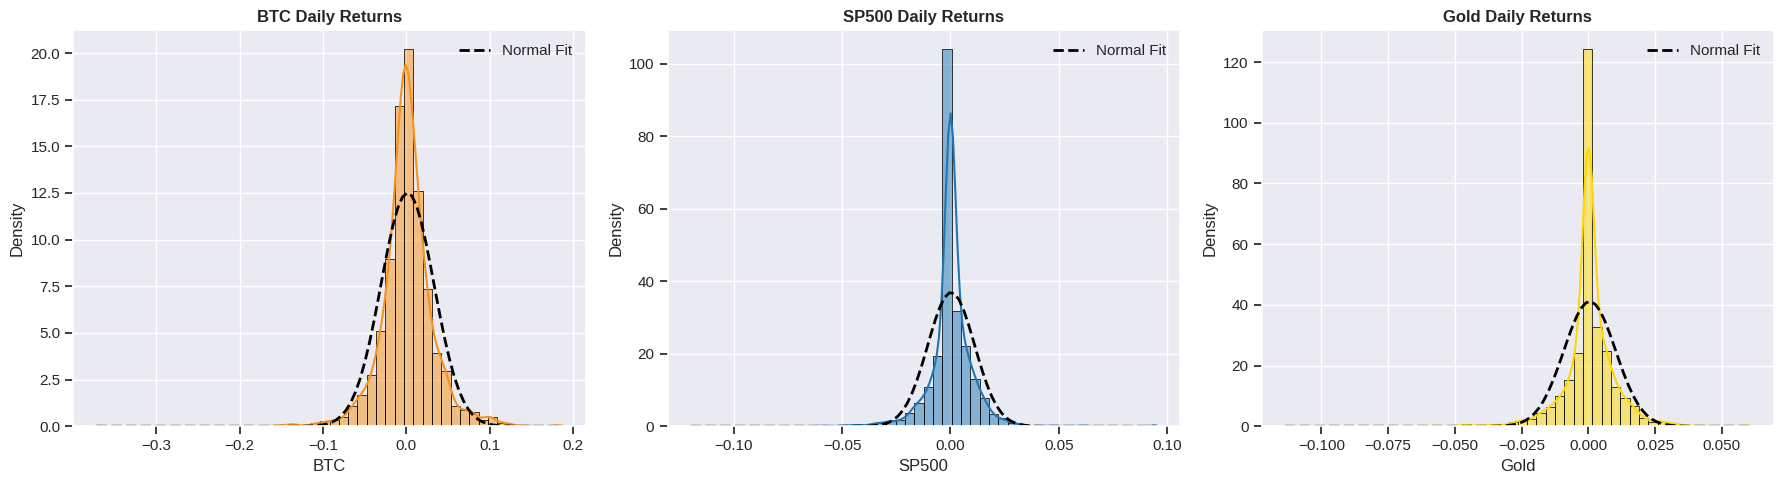

In [16]:
# Figure 4: Daily Returns Histograms with KDE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (asset, color) in enumerate(colors.items()):
    sns.histplot(returns[asset], bins=50, kde=True, ax=axes[i], color=color, stat='density')

    # Overlay Normal distribution fit
    mu, std = returns[asset].mean(), returns[asset].std()
    x = np.linspace(returns[asset].min(), returns[asset].max(), 100)
    p = stats.norm.pdf(x, mu, std)
    axes[i].plot(x, p, 'k--', linewidth=2, label='Normal Fit')

    axes[i].set_title(f'{asset} Daily Returns', fontweight='bold')
    axes[i].legend()

plt.tight_layout()
plt.show()

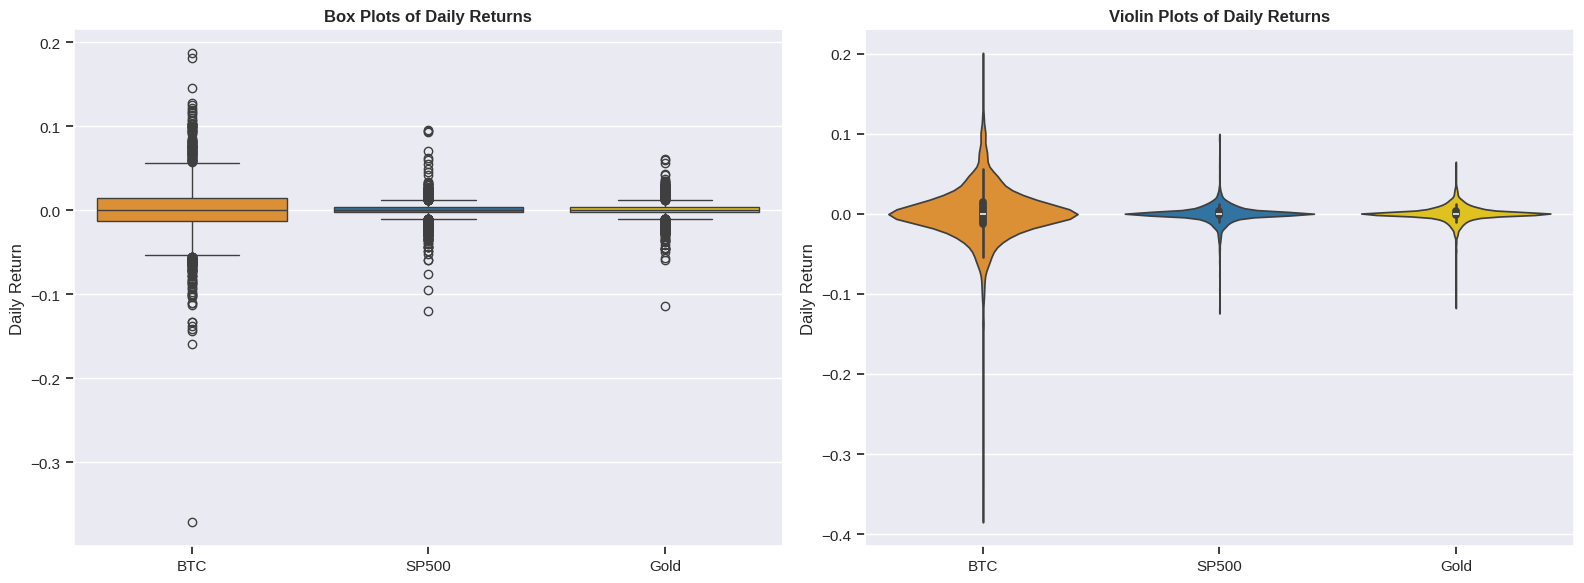

In [17]:
# Figure 5 & 6: Box Plots and Violin Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box Plot
sns.boxplot(data=returns, ax=ax1, palette=colors.values())
ax1.set_title('Box Plots of Daily Returns', fontweight='bold')
ax1.set_ylabel('Daily Return')

# Violin Plot
sns.violinplot(data=returns, ax=ax2, palette=colors.values())
ax2.set_title('Violin Plots of Daily Returns', fontweight='bold')
ax2.set_ylabel('Daily Return')

plt.tight_layout()
plt.show()

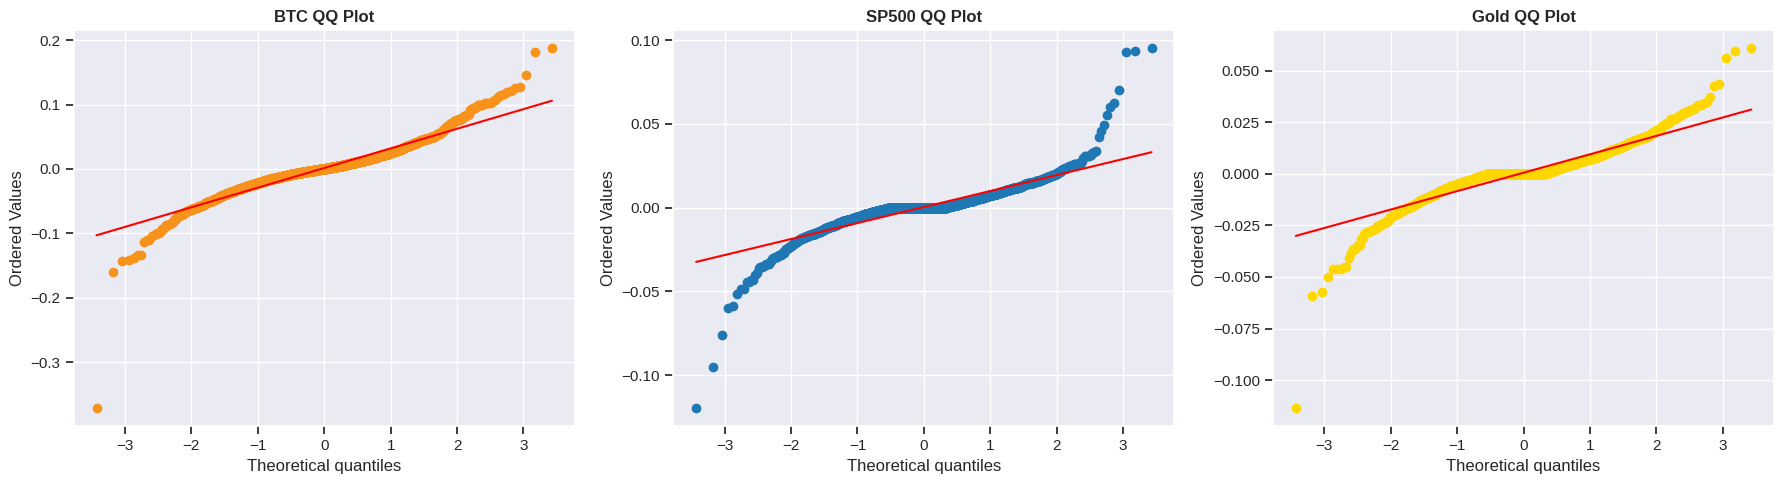

In [18]:
# Figure 7: QQ Plots for Normality
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (asset, color) in enumerate(colors.items()):
    stats.probplot(returns[asset], dist="norm", plot=axes[i])
    axes[i].get_lines()[0].set_markerfacecolor(color)
    axes[i].get_lines()[0].set_markeredgecolor(color)
    axes[i].set_title(f'{asset} QQ Plot', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:** The heavy tails in the histograms and the significant deviation from the diagonal line in the QQ plots confirm that Bitcoin returns are highly non-normal, displaying extreme volatility compared to SP500 and Gold.

---
## Section 6: Temporal Patterns
Are there specific months or years where these assets perform better?

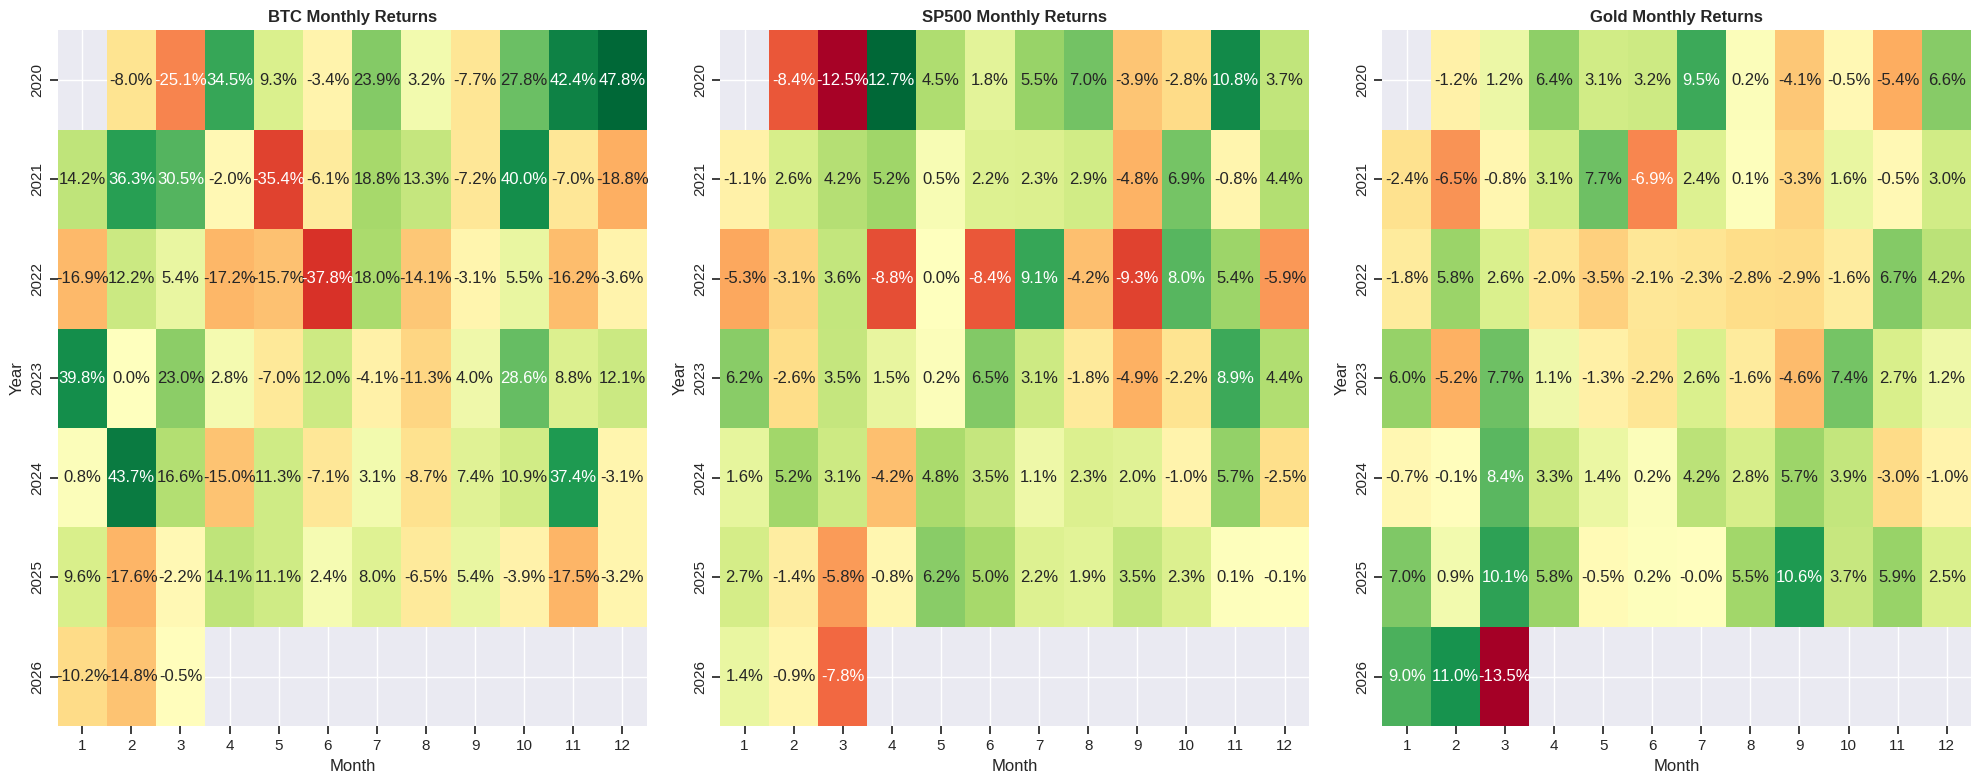

In [19]:
# Prepare data for monthly heatmap
returns_monthly = close_prices.resample('ME').last().pct_change().dropna()
returns_monthly['Year'] = returns_monthly.index.year
returns_monthly['Month'] = returns_monthly.index.month

# Figure 8: Monthly Returns Heatmap
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for i, asset in enumerate(tickers.keys()):
    pivot = returns_monthly.pivot(index='Year', columns='Month', values=asset)
    sns.heatmap(pivot, cmap='RdYlGn', annot=True, fmt='.1%', center=0, ax=axes[i], cbar=False)
    axes[i].set_title(f'{asset} Monthly Returns', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Section 7: Volatility and Drawdown Analysis

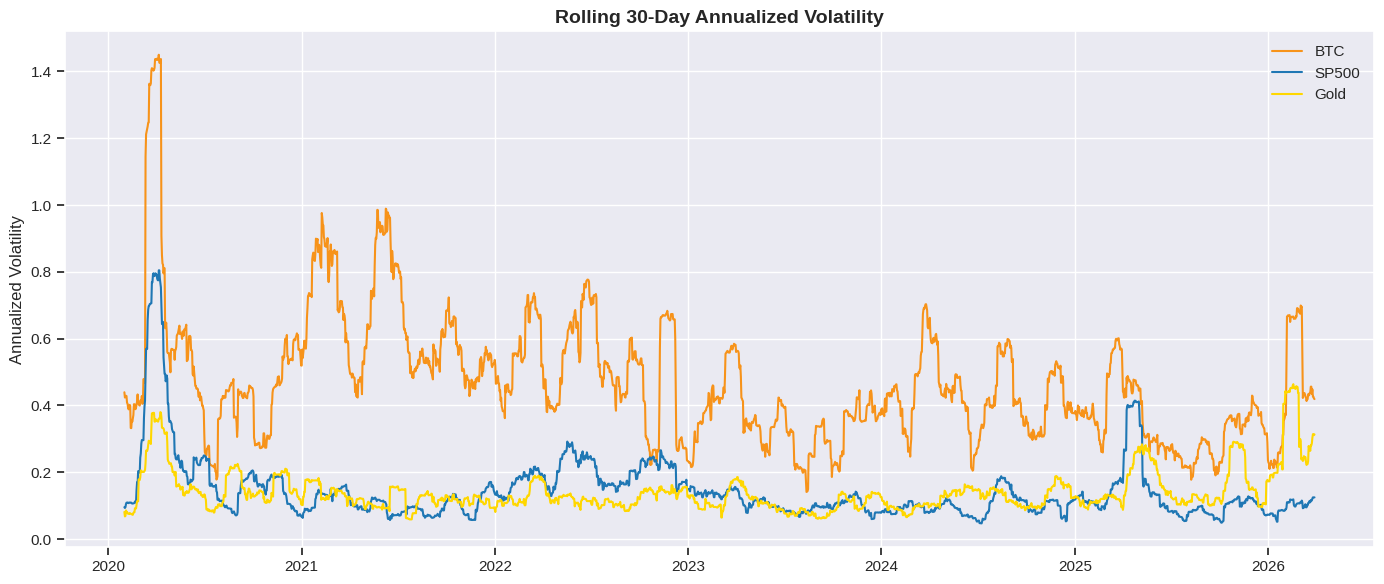

In [20]:
# Figure 11: Rolling 30-Day Volatility
rolling_vol = returns.rolling(window=30).std() * np.sqrt(252) # Annualized

plt.figure(figsize=(14, 6))
for asset, color in colors.items():
    plt.plot(rolling_vol.index, rolling_vol[asset], color=color, label=asset, linewidth=1.5)

plt.title('Rolling 30-Day Annualized Volatility', fontsize=14, fontweight='bold')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.tight_layout()
plt.show()

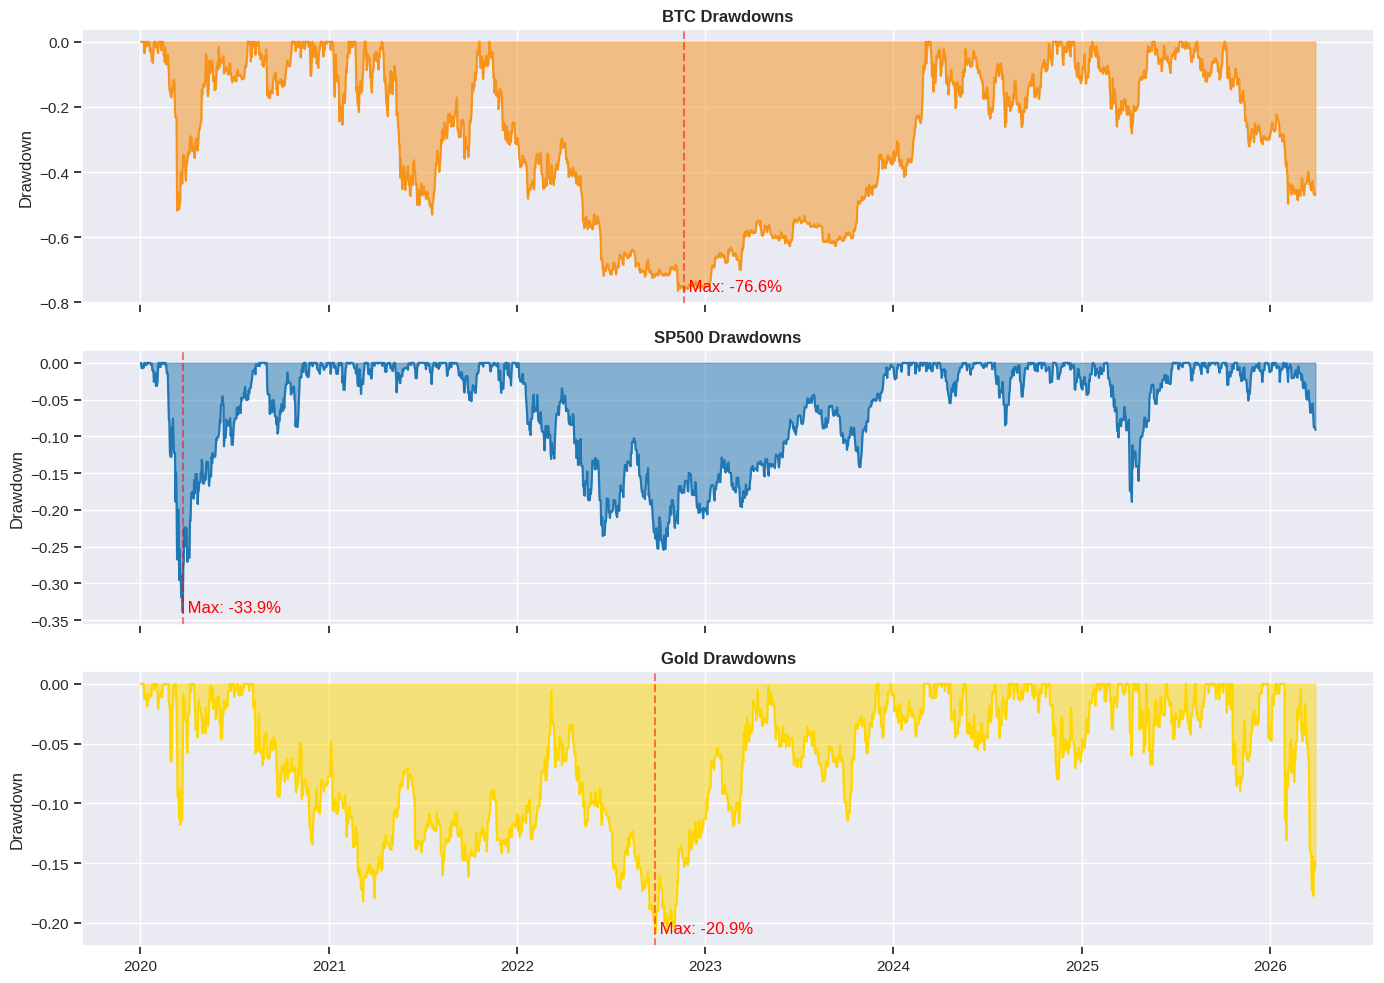

In [21]:
# Figure 12: Drawdown Analysis
rolling_max = close_prices.cummax()
drawdowns = (close_prices - rolling_max) / rolling_max

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for i, (asset, color) in enumerate(colors.items()):
    axes[i].fill_between(drawdowns.index, drawdowns[asset], 0, color=color, alpha=0.5)
    axes[i].plot(drawdowns.index, drawdowns[asset], color=color)
    axes[i].set_title(f'{asset} Drawdowns', fontweight='bold')
    axes[i].set_ylabel('Drawdown')
    # Highlight max drawdown
    min_idx = drawdowns[asset].idxmin()
    axes[i].axvline(min_idx, color='red', linestyle='--', alpha=0.5)
    axes[i].text(min_idx, drawdowns[asset].min(), f' Max: {drawdowns[asset].min():.1%}', color='red')

plt.tight_layout()
plt.show()

---
## Section 8: Correlation Analysis
This is the core of our research question: How does BTC correlate with traditional assets?

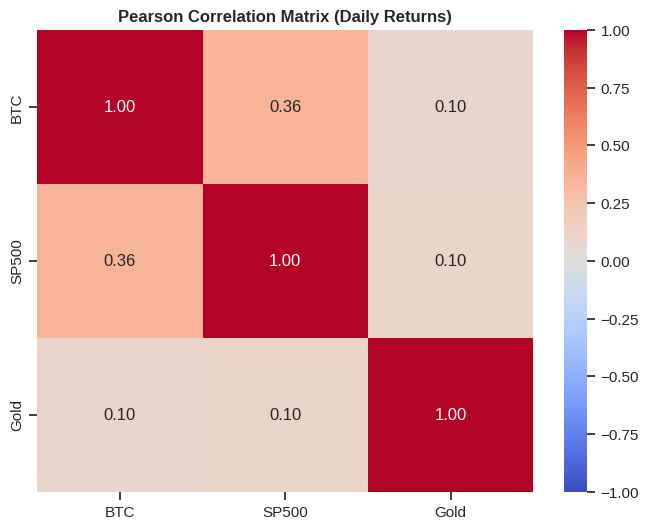

In [22]:
# Figure 13: Correlation Heatmap (Returns)
plt.figure(figsize=(8, 6))
sns.heatmap(returns.corr(method='pearson'), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f')
plt.title('Pearson Correlation Matrix (Daily Returns)', fontweight='bold')
plt.show()

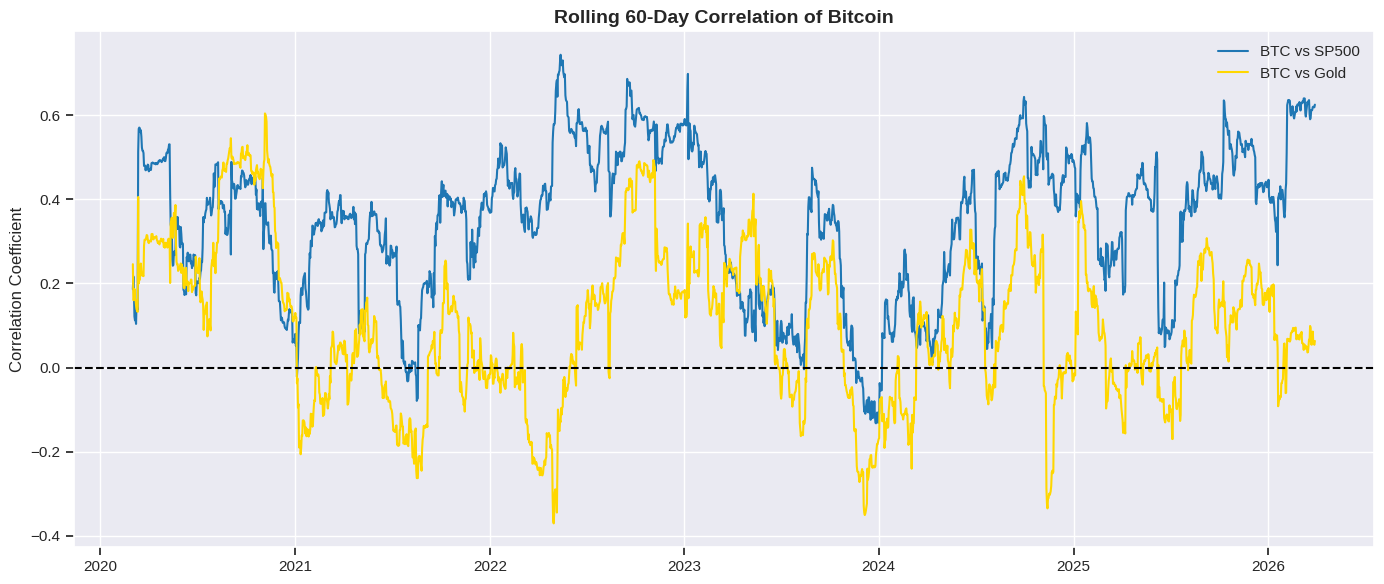

In [23]:
# Figure 15: Rolling 60-Day Correlation
rolling_corr_sp500 = returns['BTC'].rolling(60).corr(returns['SP500'])
rolling_corr_gold = returns['BTC'].rolling(60).corr(returns['Gold'])

plt.figure(figsize=(14, 6))
plt.plot(rolling_corr_sp500.index, rolling_corr_sp500, color=colors['SP500'], label='BTC vs SP500')
plt.plot(rolling_corr_gold.index, rolling_corr_gold, color=colors['Gold'], label='BTC vs Gold')
plt.axhline(0, color='black', linestyle='--')
plt.title('Rolling 60-Day Correlation of Bitcoin', fontsize=14, fontweight='bold')
plt.ylabel('Correlation Coefficient')
plt.legend()
plt.tight_layout()
plt.show()

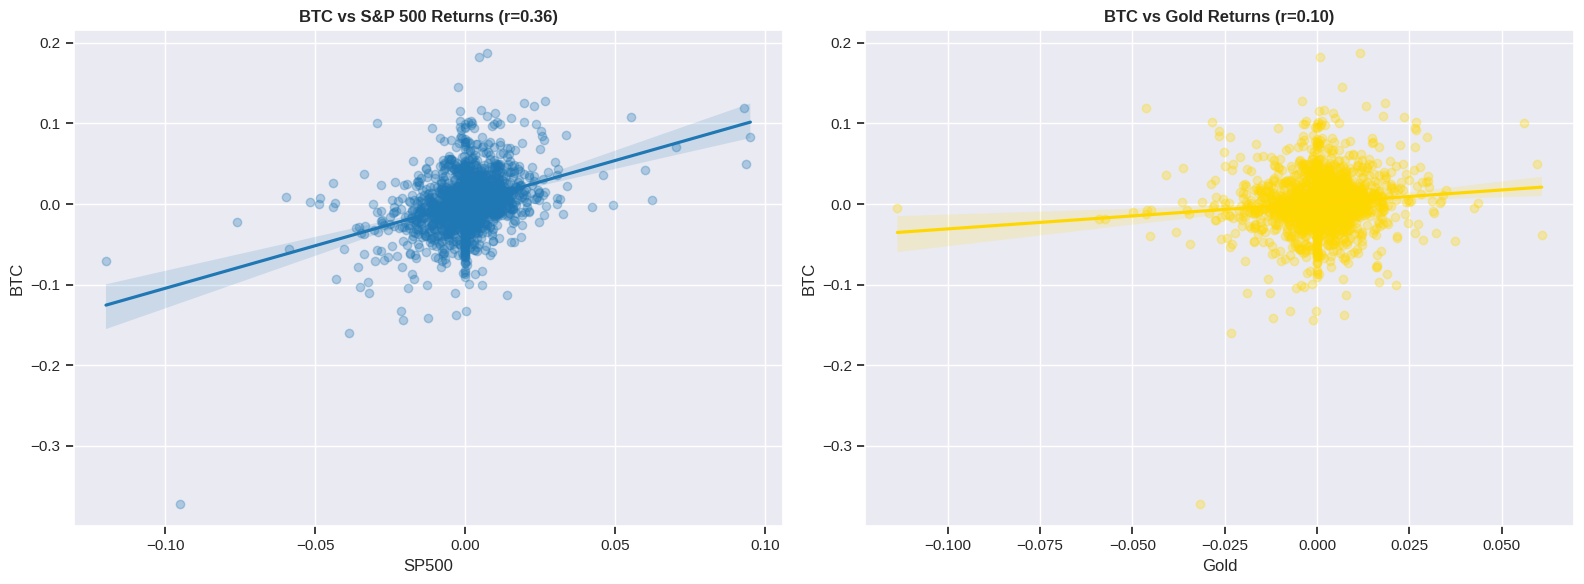

In [24]:
# Figure 16: Scatter Plots with Regression Lines
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(x=returns['SP500'], y=returns['BTC'], ax=axes[0], color=colors['SP500'], scatter_kws={'alpha':0.3})
axes[0].set_title(f"BTC vs S&P 500 Returns (r={returns['BTC'].corr(returns['SP500']):.2f})", fontweight='bold')

sns.regplot(x=returns['Gold'], y=returns['BTC'], ax=axes[1], color=colors['Gold'], scatter_kws={'alpha':0.3})
axes[1].set_title(f"BTC vs Gold Returns (r={returns['BTC'].corr(returns['Gold']):.2f})", fontweight='bold')

plt.tight_layout()
plt.show()

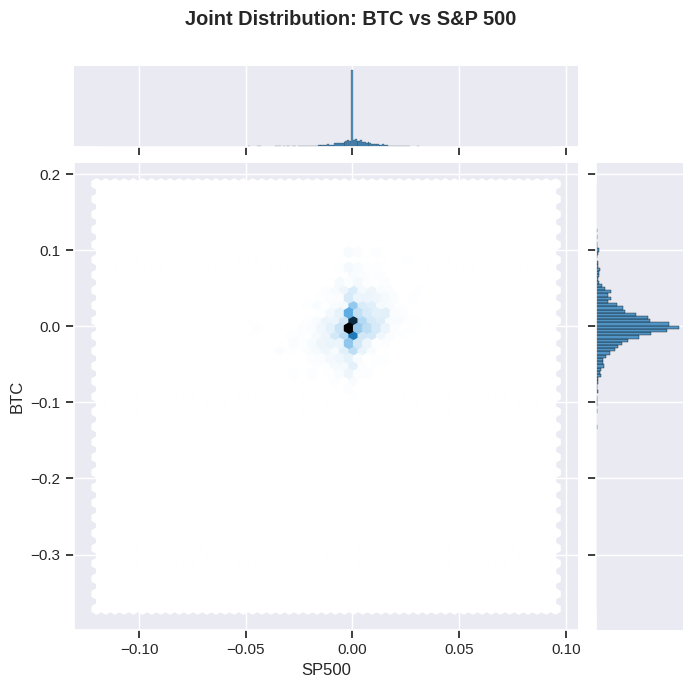

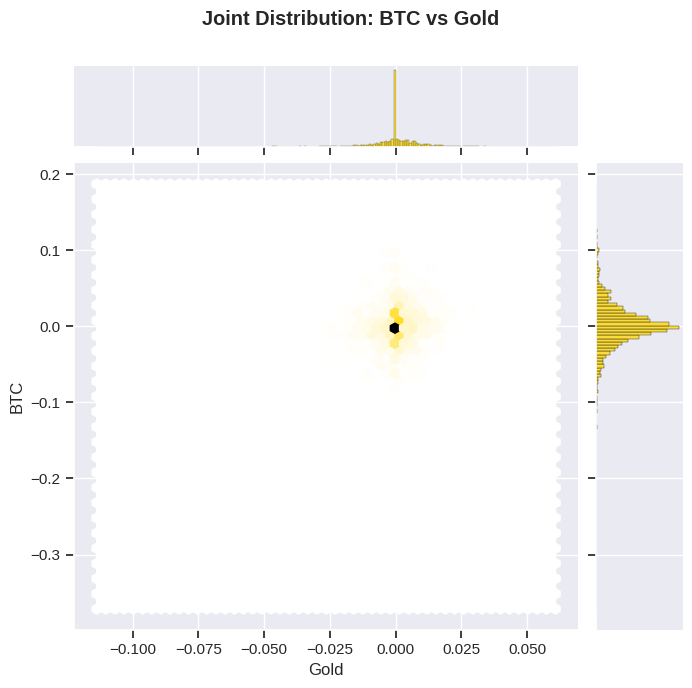

In [25]:
# Figure 17: Bivariate Joint Plots
sns.jointplot(x='SP500', y='BTC', data=returns, kind='hex', color=colors['SP500'], height=7)
plt.subplots_adjust(top=0.9)
plt.suptitle('Joint Distribution: BTC vs S&P 500', fontweight='bold')
plt.show()

sns.jointplot(x='Gold', y='BTC', data=returns, kind='hex', color=colors['Gold'], height=7)
plt.subplots_adjust(top=0.9)
plt.suptitle('Joint Distribution: BTC vs Gold', fontweight='bold')
plt.show()

---
## Section 9: Statistical Hypothesis Testing
Let's formalize our findings with rigorous statistical tests.

In [26]:
# 1. Shapiro-Wilk Test for Normality
print("Shapiro-Wilk Test for Normality (H0: Data is normally distributed)")
for asset in tickers.keys():
    # Shapiro-Wilk can struggle with N > 5000, but our N is ~1500, which is fine
    stat, p = stats.shapiro(returns[asset])
    print(f"{asset:<6} - Statistic: {stat:.4f}, p-value: {p:.4e} {'(Reject H0)' if p < 0.05 else '(Fail to reject)'}")

print("\n" + "="*60 + "\n")

# 2. Augmented Dickey-Fuller Test for Stationarity
print("ADF Test for Stationarity (H0: Data has a unit root / non-stationary)")
for asset in tickers.keys():
    result = adfuller(returns[asset])
    print(f"{asset:<6} - ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4e} {'(Stationary)' if result[1] < 0.05 else '(Non-stationary)'}")

print("\n" + "="*60 + "\n")

# 3. Granger Causality Test
print("Granger Causality: Does SP500 'cause' BTC? (H0: SP500 does NOT cause BTC)")
gc_data = returns[['BTC', 'SP500']].dropna()
# Suppress the verbose output of grangercausalitytests
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gc_res = grangercausalitytests(gc_data, maxlag=5, verbose=False)
    p_values = [gc_res[i+1][0]['ssr_ftest'][1] for i in range(5)]
    print(f"Min p-value across 5 lags: {min(p_values):.4f} {'(Significant causality)' if min(p_values) < 0.05 else '(No causality found)'}")

Shapiro-Wilk Test for Normality (H0: Data is normally distributed)
BTC    - Statistic: 0.9151, p-value: 5.8808e-34 (Reject H0)
SP500  - Statistic: 0.7837, p-value: 8.0132e-48 (Reject H0)
Gold   - Statistic: 0.8478, p-value: 2.5473e-42 (Reject H0)


ADF Test for Stationarity (H0: Data has a unit root / non-stationary)
BTC    - ADF Statistic: -15.6284, p-value: 1.6976e-28 (Stationary)
SP500  - ADF Statistic: -9.8199, p-value: 5.3734e-17 (Stationary)
Gold   - ADF Statistic: -10.2483, p-value: 4.5547e-18 (Stationary)


Granger Causality: Does SP500 'cause' BTC? (H0: SP500 does NOT cause BTC)
Min p-value across 5 lags: 0.0436 (Significant causality)


---
## Section 10: Summary & Conclusions

### Key Takeaways:
1. **High Volatility & Fat Tails:** Bitcoin is vastly more volatile than both the S&P 500 and Gold, and its return distribution is highly non-normal.
2. **Correlation with Equities:** Bitcoin shows a **moderate positive correlation** with the S&P 500. The rolling correlation reveals that this relationship strengthens during periods of market stress.
3. **Lack of Safe-Haven Status:** Bitcoin has almost **zero to weak correlation** with Gold. It does not behave like a digital safe-haven during the observed period.
4. **Time-Varying Dynamics:** The relationships are not static. The rolling correlation plot demonstrates that Bitcoin's behavior shifts dynamically over time.

**Conclusion:** Based on this exploratory analysis, **Bitcoin behaves more like a high-beta risk asset (akin to tech stocks in the S&P 500) rather than a safe-haven store of value (like Gold).**

In the next phase (Machine Learning Analysis), we will explore whether the returns of these traditional assets can be used to predict Bitcoin's price movements.